# 🎯 Système de Classification de Sentiments pour Avis Clients
## Analyse et Prédiction des Sentiments (Positif, Négatif, Neutre)

Ce notebook présente un système complet de classification de sentiments utilisant:
- **Dataset**: 171k Product Reviews from Kaggle
- **Techniques**: NLP, Machine Learning, Deep Learning
Dataset NLP de reviews produits e-commerce annotées en sentiment (≈ 171k lignes).


Contenu : nom du produit, prix, review (texte), summary (résumé), label de sentiment.
---

## 📦 1. INSTALLATION DES DÉPENDANCES

In [ ]:
# Installation des bibliothèques nécessaires
!pip install pandas numpy matplotlib seaborn scikit-learn -q
!pip install nltk wordcloud gensim -q
!pip install imbalanced-learn -q
!pip install opendatasets -q  # Pour télécharger depuis Kaggle

## 📚 2. IMPORTS ET CONFIGURATION

In [ ]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import re
from collections import Counter
import nltk

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Définir la taille par défaut des figures
plt.rcParams['figure.figsize'] = (12, 6)

# Seed pour la reproductibilité
np.random.seed(42)

print("✓ Bibliothèques importées avec succès")

✓ Bibliothèques importées avec succès


In [ ]:
# NLTK imports et téléchargements
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Télécharger les ressources NLTK nécessaires
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✓ NLTK configuré avec succès")

✓ NLTK configuré avec succès


In [ ]:
# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Gestion du déséquilibre des classes
from imblearn.over_sampling import SMOTE

print("✓ Scikit-learn importé avec succès")

✓ Scikit-learn importé avec succès


In [ ]:
# Wordcloud pour visualisation
from wordcloud import WordCloud

print("✓ WordCloud importé avec succès")

✓ WordCloud importé avec succès


In [ ]:
MAX_WORDS = 5000
MAX_SEQUENCE_LENGTH = 80

# GPU Configuration
import tensorflow as tf
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ GPU configured for optimal memory usage")
    except RuntimeError as e:
        print(f"GPU configuration: {e}")

# Reduce TensorFlow verbosity
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"✓ Optimizations loaded: MAX_WORDS={MAX_WORDS}, MAX_SEQ_LENGTH={MAX_SEQUENCE_LENGTH}")


GPU Available: False
✓ Optimizations loaded: MAX_WORDS=5000, MAX_SEQ_LENGTH=80


## 📥 3. CHARGEMENT DES DONNÉES DEPUIS KAGGLE

Nous utilisons le dataset: **171k Product Review with Sentiment**

Lien: https://www.kaggle.com/datasets/mansithummar67/171k-product-review-with-sentiment-dataset

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/nlp/sentiment.csv"

try:
    # encodages fréquents + parsing plus tolérant
    try:
        df = pd.read_csv(file_path, encoding="cp1252", sep=None, engine="python")
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding="latin1", sep=None, engine="python")

    print("✓ Dataset chargé avec succès!")
    print(f"📌 Dimensions du dataset: {df.shape}")
    display(df.head())

except FileNotFoundError:
    print("❌ Fichier non trouvé. Ajuste 'file_path'.")
except Exception as e:
    print("❌ Erreur de lecture:", repr(e))


✓ Dataset chargé avec succès!
📌 Dimensions du dataset: (171380, 6)


,ProductName,ProductPrice,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,Super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,Awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,Fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,Useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,Fair,ok ok product,neutral


## 🔍 4. EXPLORATION DES DONNÉES (EDA)

In [ ]:
# Aperçu du dataset
print("\n" + "="*80)
print("APERÇU DU DATASET")
print("="*80)
display(df.head(10))


APERÇU DU DATASET


,ProductName,ProductPrice,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,Super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,Awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,Fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,Useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,Fair,ok ok product,neutral
5,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,Awesome,the cooler is really fantastic and provides go...,positive
6,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,Highly recommended,very good product,positive
7,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,Nice,very nice,positive
8,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,Unsatisfactory,very bad cooler,negative
9,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,4,Worth the money,very good,positive


In [ ]:
# Informations générales
print("\n" + "="*80)
print("INFORMATIONS SUR LE DATASET")
print("="*80)
print(df.info())


INFORMATIONS SUR LE DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171380 entries, 0 to 171379
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   ProductName   171380 non-null  object
 1   ProductPrice  171379 non-null  object
 2   Rate          171379 non-null  object
 3   Review        171379 non-null  object
 4   Summary       171379 non-null  object
 5   Sentiment     171379 non-null  object
dtypes: object(6)
memory usage: 7.8+ MB
None


In [ ]:
# Statistiques descriptives
print("\n" + "="*80)
print("STATISTIQUES DESCRIPTIVES")
print("="*80)
display(df.describe())


STATISTIQUES DESCRIPTIVES


,ProductName,ProductPrice,Rate,Review,Summary,Sentiment
count,171380,171379,171379,171379,171379,171379
unique,963,622,6,1336,85074,6
top,Lakm?? Eyeconic Kajal Twin Pack??????????(Deep...,218,5,Nan,good,positive
freq,5000,6999,80136,24664,10864,111103


In [ ]:
# Colonnes du dataset
print("\n" + "="*80)
print("COLONNES DU DATASET")
print("="*80)
print(f"Colonnes: {df.columns.tolist()}")
print(f"\nNombre de colonnes: {len(df.columns)}")


COLONNES DU DATASET
Colonnes: ['ProductName', 'ProductPrice', 'Rate', 'Review', 'Summary', 'Sentiment']

Nombre de colonnes: 6


In [ ]:
# Vérification des valeurs manquantes
print("\n" + "="*80)
print("VALEURS MANQUANTES")
print("="*80)
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Colonne': missing_values.index,
    'Valeurs Manquantes': missing_values.values,
    'Pourcentage': missing_percentage.values
})
display(missing_df[missing_df['Valeurs Manquantes'] > 0])

if missing_df['Valeurs Manquantes'].sum() == 0:
    print("\n✓ Aucune valeur manquante détectée!")


VALEURS MANQUANTES


,Colonne,Valeurs Manquantes,Pourcentage
1,ProductPrice,1,0.000583
2,Rate,1,0.000583
3,Review,1,0.000583
4,Summary,1,0.000583
5,Sentiment,1,0.000583


Il manque uniquement 1 valeur dans chaque colonne (≈0,0006 % du dataset) : c’est négligeable


DISTRIBUTION DES SENTIMENTS

Nombre d'avis par sentiment:
  positive  : 111103 (64.83%)
  negative  :  41956 (24.48%)
  neutral   :  13692 ( 7.99%)
  Negative  :   4163 ( 2.43%)
  Neutral   :    446 ( 0.26%)
  Positive  :     19 ( 0.01%)


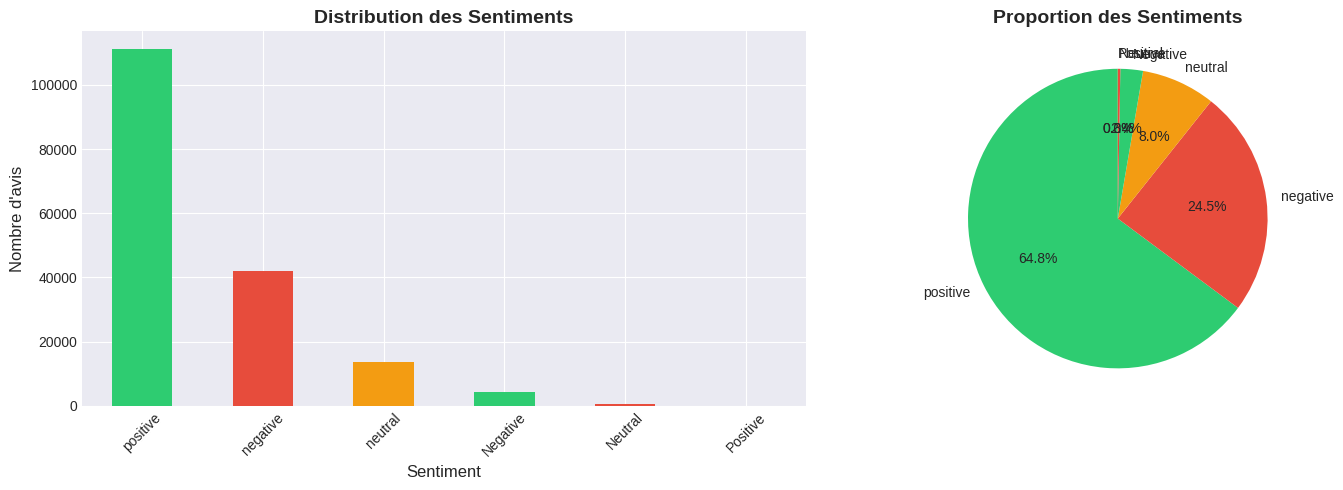

In [ ]:
# Distribution des sentiments
print("\n" + "="*80)
print("DISTRIBUTION DES SENTIMENTS")
print("="*80)

sentiment_counts = df['Sentiment'].value_counts()
sentiment_percentages = (sentiment_counts / len(df)) * 100

print("\nNombre d'avis par sentiment:")
for sentiment, count in sentiment_counts.items():
    percentage = sentiment_percentages[sentiment]
    print(f"  {sentiment:10s}: {count:6d} ({percentage:5.2f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graphique en barres
sentiment_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Distribution des Sentiments', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Nombre d\'avis', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Diagramme circulaire
colors = ['#2ecc71', '#e74c3c', '#f39c12']
sentiment_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proportion des Sentiments', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


DISTRIBUTION DES NOTES


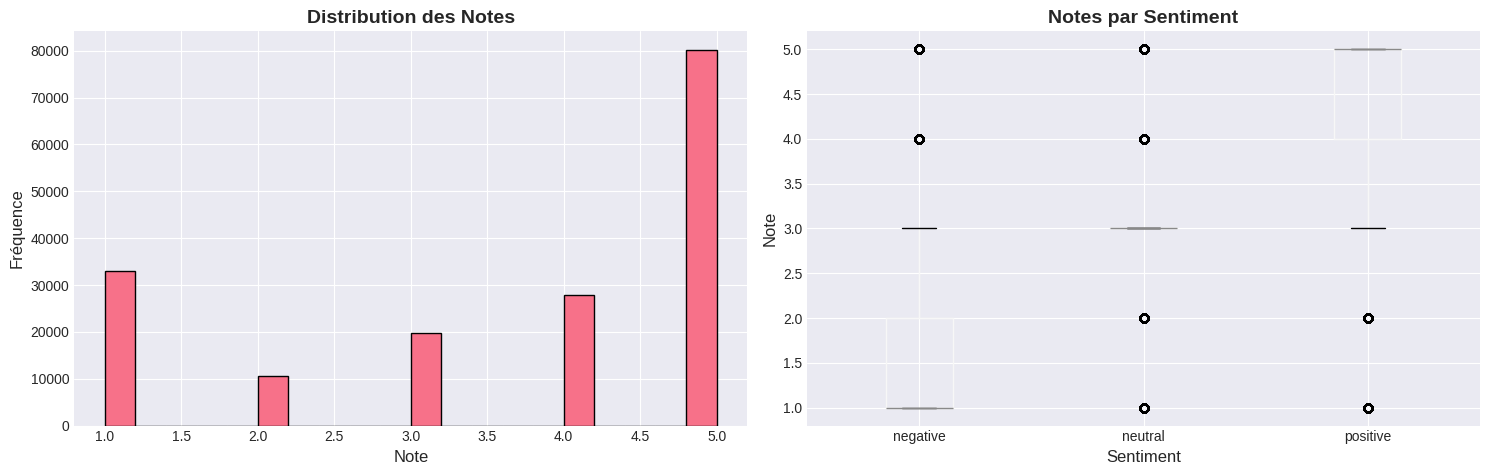


Note moyenne: 3.65
Note médiane: 4.00


In [ ]:
df["Rate"] = pd.to_numeric(df["Rate"], errors="coerce")                   # force Rate en numérique
df["Sentiment"] = df["Sentiment"].astype(str).str.strip().str.lower()     # nettoie le texte
df = df.dropna(subset=["Rate", "Sentiment"])                              # supprime lignes invalides
df = df[df["Rate"].between(1, 5)]                                         # garde notes 1..5

# --- PLOTS ---
print("\n" + "="*80)
print("DISTRIBUTION DES NOTES")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme
df["Rate"].hist(bins=20, ax=axes[0], edgecolor="black")
axes[0].set_title("Distribution des Notes", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Note", fontsize=12)
axes[0].set_ylabel("Fréquence", fontsize=12)

# Boxplot par sentiment
df.boxplot(column="Rate", by="Sentiment", ax=axes[1])
axes[1].set_title("Notes par Sentiment", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Sentiment", fontsize=12)
axes[1].set_ylabel("Note", fontsize=12)

plt.suptitle("")
plt.tight_layout()
plt.show()

print(f"\nNote moyenne: {df['Rate'].mean():.2f}")
print(f"Note médiane: {df['Rate'].median():.2f}")


ANALYSE DE LA LONGUEUR DES AVIS

Statistiques de longueur:
  Longueur moyenne: 11 caractères
  Longueur médiane: 10 caractères
  Nombre moyen de mots: 2 mots


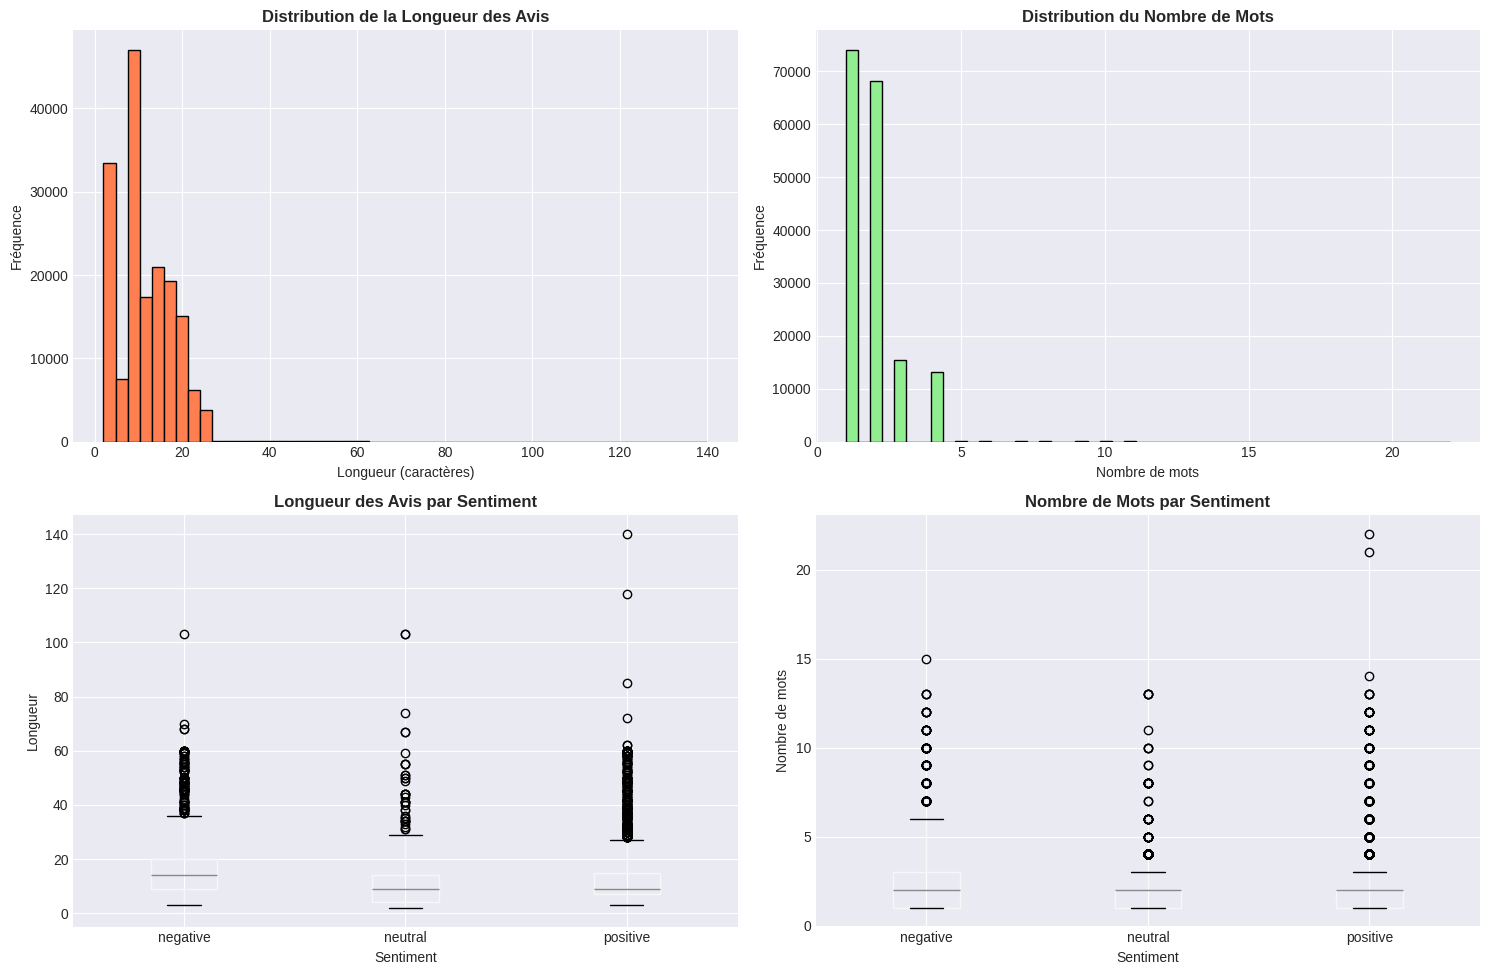

In [ ]:
# Analyse de la longueur des avis
print("\n" + "="*80)
print("ANALYSE DE LA LONGUEUR DES AVIS")
print("="*80)

# Créer une colonne pour la longueur des reviews
df['review_length'] = df['Review'].astype(str).apply(len)
df['review_word_count'] = df['Review'].astype(str).apply(lambda x: len(x.split()))

print("\nStatistiques de longueur:")
print(f"  Longueur moyenne: {df['review_length'].mean():.0f} caractères")
print(f"  Longueur médiane: {df['review_length'].median():.0f} caractères")
print(f"  Nombre moyen de mots: {df['review_word_count'].mean():.0f} mots")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution de la longueur
df['review_length'].hist(bins=50, ax=axes[0, 0], color='coral', edgecolor='black')
axes[0, 0].set_title('Distribution de la Longueur des Avis', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Longueur (caractères)')
axes[0, 0].set_ylabel('Fréquence')

# Distribution du nombre de mots
df['review_word_count'].hist(bins=50, ax=axes[0, 1], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution du Nombre de Mots', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Nombre de mots')
axes[0, 1].set_ylabel('Fréquence')

# Boxplot longueur par sentiment
df.boxplot(column='review_length', by='Sentiment', ax=axes[1, 0])
axes[1, 0].set_title('Longueur des Avis par Sentiment', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sentiment')
axes[1, 0].set_ylabel('Longueur')

# Boxplot mots par sentiment
df.boxplot(column='review_word_count', by='Sentiment', ax=axes[1, 1])
axes[1, 1].set_title('Nombre de Mots par Sentiment', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sentiment')
axes[1, 1].set_ylabel('Nombre de mots')

plt.suptitle('')
plt.tight_layout()
plt.show()


TOP 10 PRODUITS LES PLUS COMMENTÉS
ProductName
Lakm?? Eyeconic Kajal Twin Pack??????????(Deep Black, 0.7 g)                                                                                                  5000
Mi 5A 80 cm (32 inch) HD Ready LED Smart Android TV with Dolby Audio (2022 Model)                                                                             2646
Mi 3i 10000 mAh Power Bank (Fast Charging, 18W)ÃÂÃÂ?ÃÂÃÂ®ÃÂÃÂ ÃÂÃÂ?ÃÂÃÂ®ÃÂÃÂ (Blue, Lithium Polymer)                                      2006
Singer FM 1409 Electric Sewing MachineÃÂÃÂ?ÃÂÃÂ®ÃÂÃÂ ÃÂÃÂ?ÃÂÃÂ®ÃÂÃÂ ( Built-in Stitches 9)                                                2003
Men Cargos                                                                                                                                                    2000
POCO C31 (Royal Blue, 64 GB)?ÃÂÃÂÃÂÃÂ?ÃÂÃÂÃÂÃÂ(4 GB RAM)                                                                 

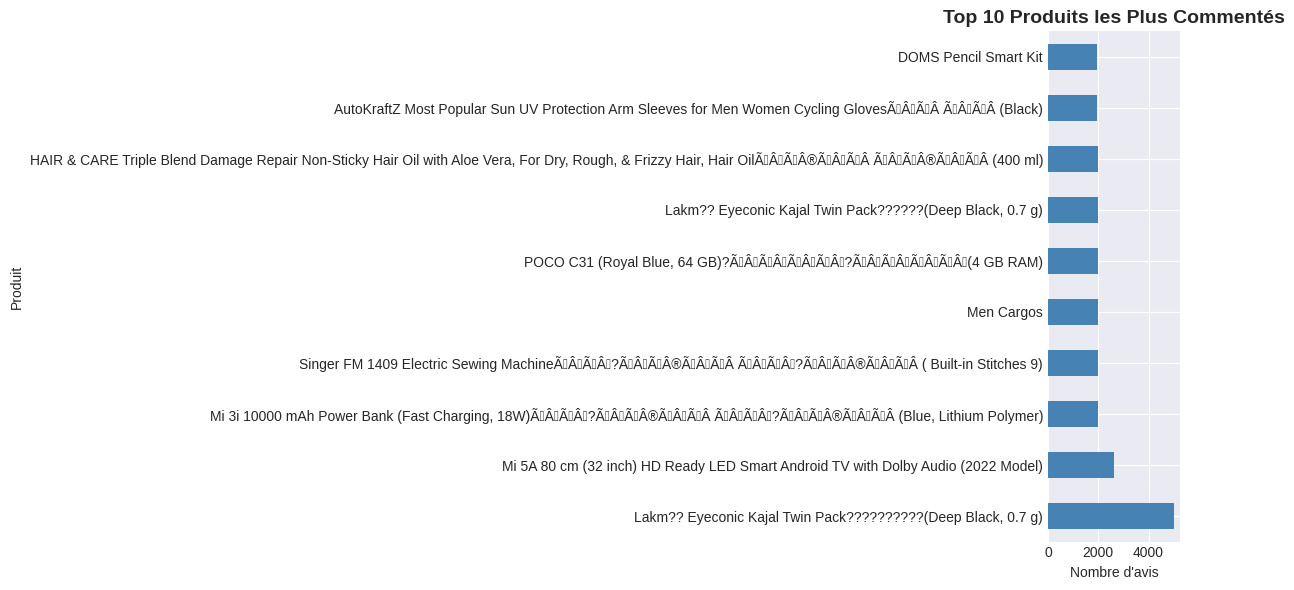

In [ ]:
# Top produits les plus commentés
print("\n" + "="*80)
print("TOP 10 PRODUITS LES PLUS COMMENTÉS")
print("="*80)

top_products = df['ProductName'].value_counts().head(10)
print(top_products)

# Visualisation
plt.figure(figsize=(12, 6))
top_products.plot(kind='barh', color='steelblue')
plt.title('Top 10 Produits les Plus Commentés', fontsize=14, fontweight='bold')
plt.xlabel('Nombre d\'avis')
plt.ylabel('Produit')
plt.tight_layout()
plt.show()


WORDCLOUDS PAR SENTIMENT


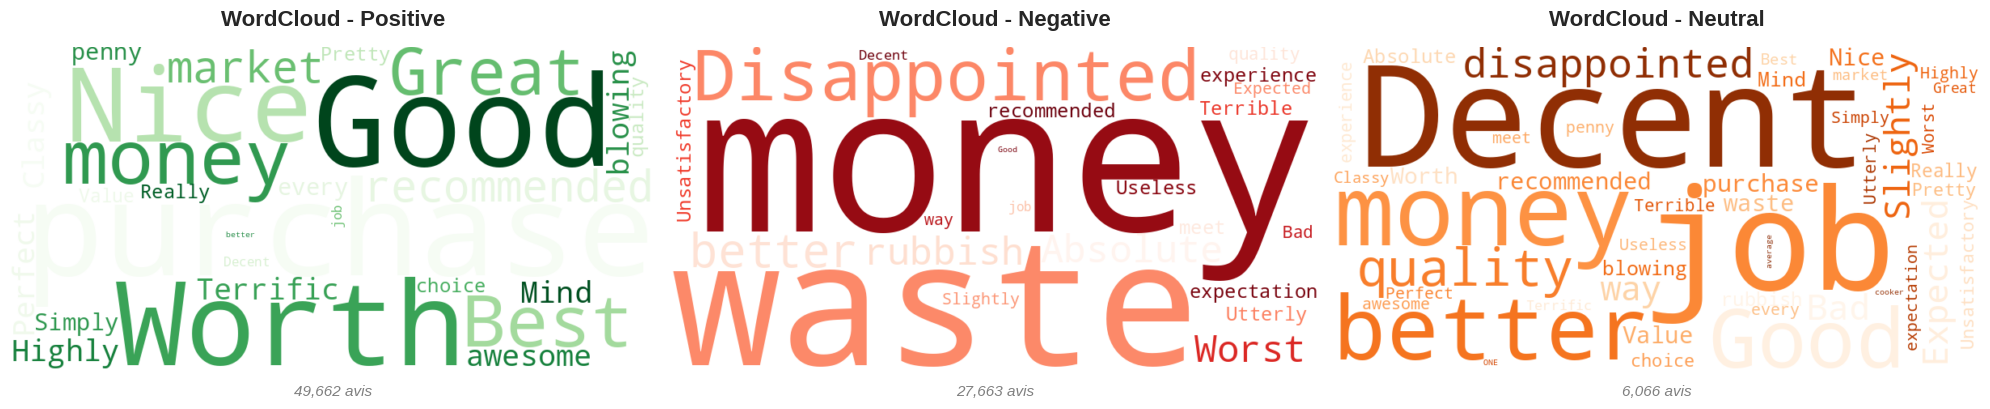


✓ WordClouds créés sans 'Nan'


In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("WORDCLOUDS PAR SENTIMENT")
print("="*80)

# Stopwords personnalisés incluant "Nan" et autres mots à exclure
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'nan', 'Nan', 'NaN', 'NAN',  # Variantes de Nan
    'none', 'None',               # None
    'product', 'bought', 'buy', 'purchased',  # Mots trop génériques
])

sentiments = df['Sentiment'].unique()
fig, axes = plt.subplots(1, len(sentiments), figsize=(20, 6))

if len(sentiments) == 1:
    axes = [axes]

# Couleurs par sentiment
colormap_dict = {
    'positive': 'Greens',
    'negative': 'Reds',
    'neutral': 'Oranges'
}

for idx, sentiment in enumerate(sentiments):
    # Filtrer les avis valides
    reviews = df[df['Sentiment'] == sentiment]['Review'].dropna()
    reviews = reviews[reviews.str.len() > 10]  # Avis avec au moins 10 caractères

    if len(reviews) == 0:
        axes[idx].text(0.5, 0.5, 'Aucune donnée',
                      ha='center', va='center', fontsize=14)
        axes[idx].axis('off')
        continue

    # Combiner tous les avis
    text = ' '.join(reviews.astype(str))

    # Créer le WordCloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colormap_dict.get(sentiment.lower(), 'viridis'),
        max_words=100,
        stopwords=custom_stopwords,
        relative_scaling=0.5,
        min_font_size=10,
        collocations=False  # Éviter les répétitions
    ).generate(text)

    # Afficher
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'WordCloud - {sentiment.capitalize()}',
                        fontsize=16, fontweight='bold', pad=15)
    axes[idx].axis('off')

    # Afficher le nombre d'avis
    axes[idx].text(0.5, -0.08, f'{len(reviews):,} avis',
                  ha='center', transform=axes[idx].transAxes,
                  fontsize=11, color='gray', style='italic')

plt.tight_layout()
plt.show()

print(f"\n✓ WordClouds créés sans 'Nan'")

## 🔍 4.5. ANALYSE LINGUISTIQUE AVANCÉE

Analyse approfondie du texte : POS tagging, extraction d'adjectifs, et reconnaissance d'entités nommées (NER)


In [ ]:
# Installation de spaCy pour NER
try:
    import spacy
    print("✓ spaCy déjà installé")
except ImportError:
    print("Installation de spaCy...")
    !pip install spacy -q
    !python -m spacy download en_core_web_sm -q
    import spacy
    print("✓ spaCy installé")

# Charger le modèle
try:
    nlp = spacy.load('en_core_web_sm')
    print("✓ Modèle spaCy chargé")
except:
    !python -m spacy download en_core_web_sm -q
    nlp = spacy.load('en_core_web_sm')
    print("✓ Modèle spaCy téléchargé et chargé")


✓ spaCy déjà installé
✓ Modèle spaCy chargé


### 📌 4.5.1. POS Tagging (Part-of-Speech)

Analyse grammaticale des textes pour identifier les types de mots.


Téléchargement des ressources NLTK...
✓ Ressources téléchargées

POS TAGGING - ANALYSE GRAMMATICALE

Analyse de 1000 avis...

📊 Distribution des types de mots (sur 1000 avis):

Tag | Description           | Fréquence
--------------------------------------------------
NOUN | Noms                 | 923
ADJ  | Adjectifs            | 380
ADV  | Adverbes             | 208
.    | Ponctuation          | 185
VERB | Verbes               | 149
DET  | Déterminants         | 97
ADP  | Prépositions         | 64
PRON | Pronoms              | 33
CONJ | Conjonctions         | 2
NUM  | Nombres              | 1


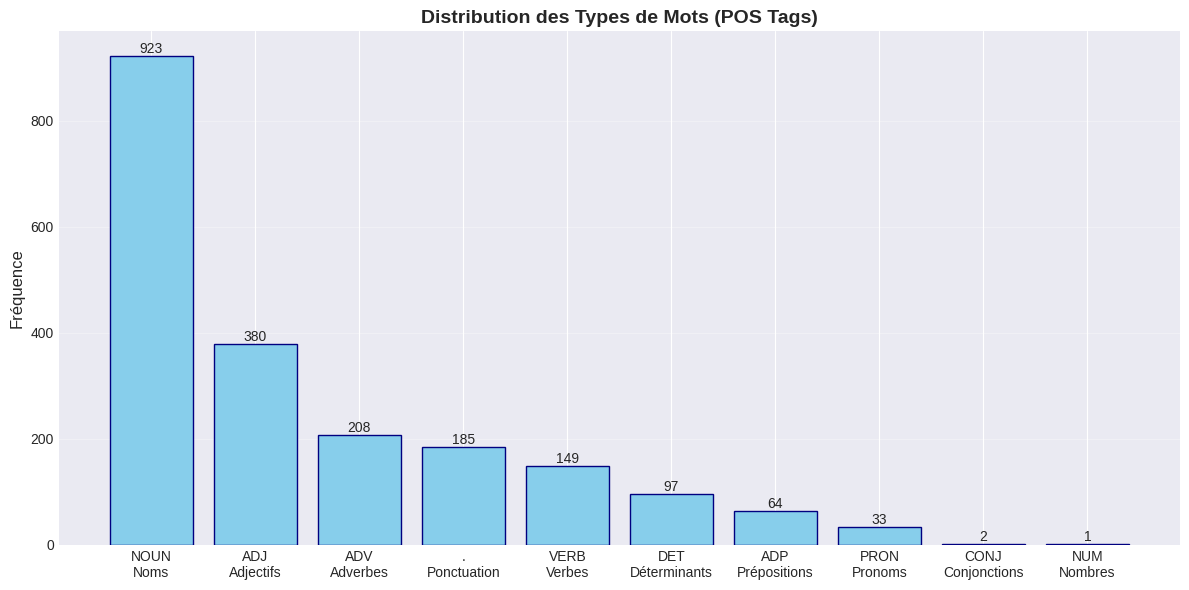


✓ POS Tagging terminé sur 1000 avis


In [ ]:
from collections import Counter
import nltk

# Télécharger toutes les ressources NLTK nécessaires
print("Téléchargement des ressources NLTK...")
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)  # Version anglaise
nltk.download('universal_tagset', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)  # NOUVELLE RESSOURCE
print("✓ Ressources téléchargées")

print("\n" + "="*80)
print("POS TAGGING - ANALYSE GRAMMATICALE")
print("="*80)

# Échantillon de 1000 avis
sample_size = 1000
sample_reviews = df['Review'].sample(n=min(sample_size, len(df)), random_state=42)

# POS tagging sur l'échantillon
all_pos_tags = []
print(f"\nAnalyse de {sample_size} avis...")

for review in sample_reviews:
    words = word_tokenize(str(review))
    pos_tags = nltk.pos_tag(words, tagset='universal')
    all_pos_tags.extend([tag for word, tag in pos_tags])

# Compter les POS tags
pos_counts = Counter(all_pos_tags)

print(f"\n📊 Distribution des types de mots (sur {sample_size} avis):")
print("\nTag | Description           | Fréquence")
print("-" * 50)
pos_descriptions = {
    'NOUN': 'Noms',
    'VERB': 'Verbes',
    'ADJ': 'Adjectifs',
    'ADV': 'Adverbes',
    'PRON': 'Pronoms',
    'DET': 'Déterminants',
    'ADP': 'Prépositions',
    'CONJ': 'Conjonctions',
    'NUM': 'Nombres',
    'PRT': 'Particules',
    '.': 'Ponctuation',
    'X': 'Autres'
}

for tag, count in pos_counts.most_common():
    desc = pos_descriptions.get(tag, tag)
    print(f"{tag:4} | {desc:20} | {count:,}")

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
top_pos = dict(pos_counts.most_common(10))
bars = ax.bar(range(len(top_pos)), list(top_pos.values()), color='skyblue', edgecolor='navy')
ax.set_xticks(range(len(top_pos)))
ax.set_xticklabels([f"{tag}\n{pos_descriptions.get(tag, tag)}" for tag in top_pos.keys()], rotation=0)
ax.set_ylabel('Fréquence', fontsize=12)
ax.set_title('Distribution des Types de Mots (POS Tags)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n✓ POS Tagging terminé sur {sample_size} avis")

### 📌 4.5.2. Extraction des Adjectifs Fréquents

Identification des adjectifs les plus utilisés pour chaque sentiment.



EXTRACTION DES ADJECTIFS FRÉQUENTS PAR SENTIMENT

📊 Top 15 adjectifs - Sentiment 'NEGATIVE':
--------------------------------------------------
  disappointed         :   39 fois
  terrible             :   24 fois
  horrible             :   24 fois
  poor                 :   22 fois
  useless              :   20 fois
  absolute             :   19 fois
  good                 :   19 fois
  worst                :   14 fois
  bad                  :   11 fois
  decent               :   11 fois
  nice                 :   11 fois
  better               :   11 fois
  great                :    2 fois
  other                :    1 fois
  rbstore              :    1 fois

📊 Top 15 adjectifs - Sentiment 'NEUTRAL':
--------------------------------------------------
  good                 :   69 fois
  decent               :   41 fois
  nice                 :   38 fois
  disappointed         :   20 fois
  bad                  :    9 fois
  absolute             :    8 fois
  fabulous             :  

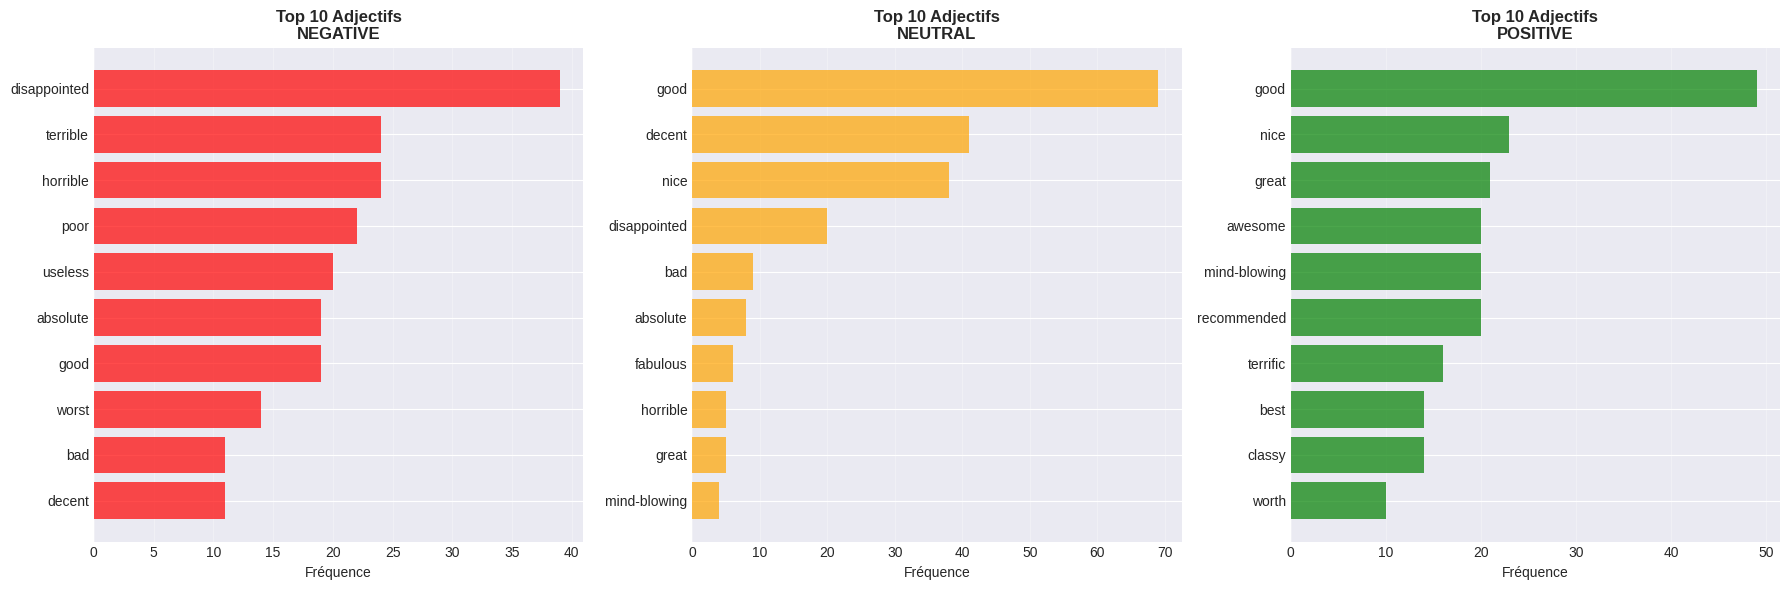


✓ Extraction des adjectifs terminée


In [ ]:
print("\n" + "="*80)
print("EXTRACTION DES ADJECTIFS FRÉQUENTS PAR SENTIMENT")
print("="*80)

# Fonction pour extraire les adjectifs
def extract_adjectives(text, top_n=20):
    words = word_tokenize(str(text).lower())
    pos_tags = nltk.pos_tag(words, tagset='universal')
    adjectives = [word for word, tag in pos_tags if tag == 'ADJ' and len(word) > 2]
    return adjectives

# Extraire les adjectifs par sentiment
adjectives_by_sentiment = {}
for sentiment in df['Sentiment'].unique():
    reviews = df[df['Sentiment'] == sentiment]['Review']
    all_adjectives = []

    # Échantillonner pour la performance
    sample_reviews = reviews.sample(n=min(500, len(reviews)), random_state=42)

    for review in sample_reviews:
        all_adjectives.extend(extract_adjectives(review))

    adjectives_by_sentiment[sentiment] = Counter(all_adjectives)

# Afficher les top adjectifs par sentiment
for sentiment in sorted(adjectives_by_sentiment.keys()):
    print(f"\n📊 Top 15 adjectifs - Sentiment '{sentiment.upper()}':")
    print("-" * 50)
    for adj, count in adjectives_by_sentiment[sentiment].most_common(15):
        print(f"  {adj:20} : {count:4} fois")

# Visualisation comparative
fig, axes = plt.subplots(1, len(adjectives_by_sentiment), figsize=(18, 6))
if len(adjectives_by_sentiment) == 1:
    axes = [axes]

colors_map = {
    'positive': 'green',
    'negative': 'red',
    'neutral': 'orange'
}

for idx, (sentiment, counter) in enumerate(sorted(adjectives_by_sentiment.items())):
    top_adj = dict(counter.most_common(10))

    axes[idx].barh(range(len(top_adj)), list(top_adj.values()),
                   color=colors_map.get(sentiment, 'skyblue'), alpha=0.7)
    axes[idx].set_yticks(range(len(top_adj)))
    axes[idx].set_yticklabels(list(top_adj.keys()))
    axes[idx].set_xlabel('Fréquence', fontsize=10)
    axes[idx].set_title(f'Top 10 Adjectifs\n{sentiment.upper()}',
                       fontsize=12, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n✓ Extraction des adjectifs terminée")


### 📌 4.5.3. Reconnaissance d'Entités Nommées (NER)

Identification des entités (personnes, organisations, lieux, produits) dans les avis.



RECONNAISSANCE D'ENTITÉS NOMMÉES (NER)

Analyse de 200 avis...

✓ 9 entités détectées

📊 Types d'entités détectées:
------------------------------------------------------------
Type                 | Description                    | Nombre  
------------------------------------------------------------
ORG                  | Organisations/Entreprises      |        9

📌 Exemples d'entités les plus fréquentes:

Organisations/Entreprises (ORG):
  • Terrific: 5 fois
  • Worthless: 2 fois
  • Utterly: 1 fois
  • Flipkart: 1 fois


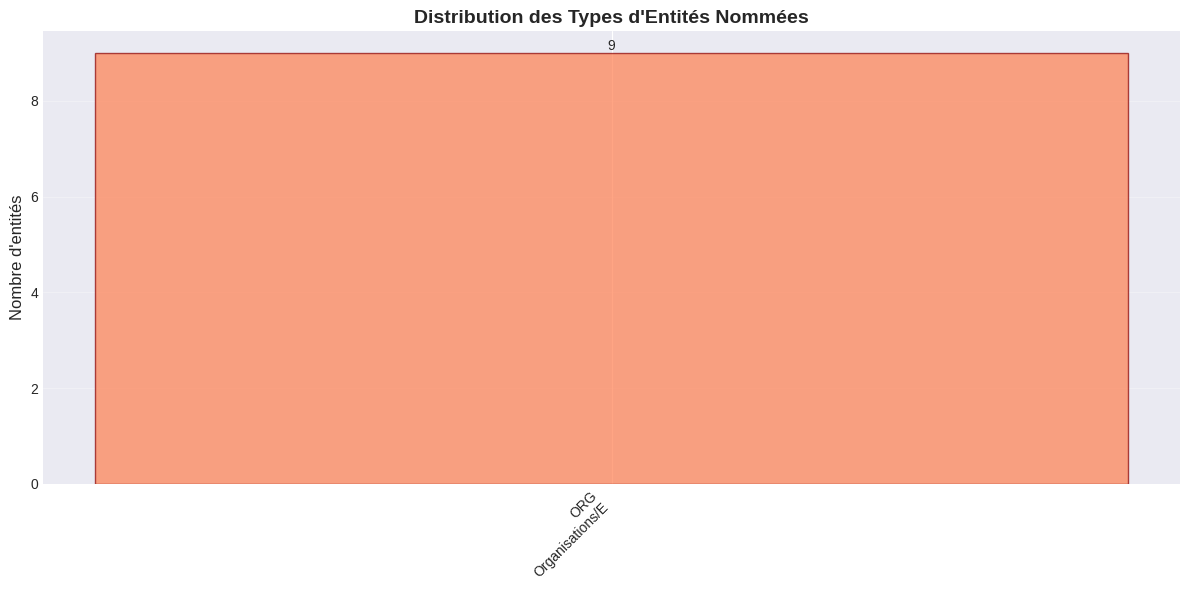


✓ Analyse NER terminée sur 200 avis


In [ ]:
print("\n" + "="*80)
print("RECONNAISSANCE D'ENTITÉS NOMMÉES (NER)")
print("="*80)

# Analyse NER sur un échantillon
sample_size_ner = 200
sample_ner = df['Review'].sample(n=min(sample_size_ner, len(df)), random_state=42)

all_entities = []
entity_by_type = {}

print(f"\nAnalyse de {sample_size_ner} avis...")

for review in sample_ner:
    doc = nlp(str(review)[:1000])  # Limiter à 1000 caractères pour la performance
    for ent in doc.ents:
        all_entities.append((ent.text, ent.label_))
        if ent.label_ not in entity_by_type:
            entity_by_type[ent.label_] = []
        entity_by_type[ent.label_].append(ent.text)

print(f"\n✓ {len(all_entities)} entités détectées")

# Compter les types d'entités
entity_type_counts = Counter([label for text, label in all_entities])

print("\n📊 Types d'entités détectées:")
print("-" * 60)
print(f"{'Type':20} | {'Description':30} | {'Nombre':8}")
print("-" * 60)

entity_descriptions = {
    'PERSON': 'Personnes',
    'ORG': 'Organisations/Entreprises',
    'GPE': 'Pays/Villes/États',
    'PRODUCT': 'Produits',
    'DATE': 'Dates',
    'TIME': 'Heures',
    'MONEY': 'Montants monétaires',
    'CARDINAL': 'Nombres',
    'ORDINAL': 'Ordinaux (1er, 2ème...)',
    'QUANTITY': 'Quantités',
    'PERCENT': 'Pourcentages',
    'LOC': 'Lieux non-GPE',
    'NORP': 'Nationalités/Groupes'
}

for entity_type, count in entity_type_counts.most_common():
    desc = entity_descriptions.get(entity_type, entity_type)
    print(f"{entity_type:20} | {desc:30} | {count:8}")

# Top entités par type
print("\n📌 Exemples d'entités les plus fréquentes:")
for entity_type in ['PERSON', 'ORG', 'PRODUCT', 'GPE']:
    if entity_type in entity_by_type:
        entities = Counter(entity_by_type[entity_type])
        print(f"\n{entity_descriptions.get(entity_type, entity_type)} ({entity_type}):")
        for entity, count in entities.most_common(5):
            print(f"  • {entity}: {count} fois")

# Visualisation
if len(entity_type_counts) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    top_types = dict(entity_type_counts.most_common(10))

    bars = ax.bar(range(len(top_types)), list(top_types.values()),
                  color='coral', edgecolor='darkred', alpha=0.7)
    ax.set_xticks(range(len(top_types)))
    ax.set_xticklabels([f"{t}\n{entity_descriptions.get(t, t)[:15]}"
                        for t in top_types.keys()], rotation=45, ha='right')
    ax.set_ylabel('Nombre d\'entités', fontsize=12)
    ax.set_title('Distribution des Types d\'Entités Nommées', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Ajouter les valeurs
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

print(f"\n✓ Analyse NER terminée sur {sample_size_ner} avis")


## 🧹 5. PRÉTRAITEMENT DES DONNÉES

In [ ]:
# Fonction de nettoyage de texte
def clean_text(text):
    """
    Nettoie le texte en:
    - Convertissant en minuscules
    - Supprimant les URLs
    - Supprimant les caractères spéciaux
    - Supprimant les chiffres
    - Supprimant les espaces multiples
    """
    if pd.isna(text):
        return ""

    # Convertir en string si ce n'est pas déjà le cas
    text = str(text)

    # Minuscules
    text = text.lower()

    # Supprimer les URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Supprimer les mentions @ et #
    text = re.sub(r'@\w+|#\w+', '', text)

    # Supprimer les caractères spéciaux et chiffres
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("✓ Fonction de nettoyage définie")

✓ Fonction de nettoyage définie


In [ ]:
# Fonction de prétraitement avancé
def preprocess_text(text):
    """
    Prétraite le texte en:
    - Nettoyant le texte
    - Tokenisant
    - Supprimant les stopwords
    - Lemmatisant
    """
    # Nettoyer
    text = clean_text(text)

    if not text:
        return ""

    # Tokeniser
    tokens = word_tokenize(text)

    # Supprimer les stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    # Lemmatiser
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

print("✓ Fonction de prétraitement définie")

✓ Fonction de prétraitement définie


In [ ]:
# Appliquer le nettoyage
print("\nDébut du nettoyage des données...")
print("⏳ Cela peut prendre quelques minutes...\n")

# Créer une copie du dataframe
df_clean = df.copy()

# Nettoyer les avis
df_clean['Review_cleaned'] = df_clean['Review'].apply(clean_text)

print("✓ Nettoyage de base terminé")


# Téléchargements requis par NLTK
nltk.download("punkt")
nltk.download("punkt_tab")
# Prétraitement avancé (peut être long)
df_clean['Review_processed'] = df_clean['Review'].apply(preprocess_text)

print("✓ Prétraitement avancé terminé")

# Afficher des exemples
print("\n" + "="*80)
print("EXEMPLES DE PRÉTRAITEMENT")
print("="*80)

for i in range(3):
    print(f"\nExemple {i+1}:")
    print(f"  Original: {df['Review'].iloc[i][:100]}...")
    print(f"  Nettoyé: {df_clean['Review_cleaned'].iloc[i][:100]}...")
    print(f"  Traité: {df_clean['Review_processed'].iloc[i][:100]}...")


Début du nettoyage des données...
⏳ Cela peut prendre quelques minutes...

✓ Nettoyage de base terminé


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


✓ Prétraitement avancé terminé

EXEMPLES DE PRÉTRAITEMENT

Exemple 1:
  Original: Super!...
  Nettoyé: super...
  Traité: super...

Exemple 2:
  Original: Awesome...
  Nettoyé: awesome...
  Traité: awesome...

Exemple 3:
  Original: Fair...
  Nettoyé: fair...
  Traité: fair...


In [ ]:
# Supprimer les lignes vides après prétraitement
df_clean = df_clean[df_clean['Review_processed'].str.len() > 0]

print(f"\n✓ Dataset nettoyé: {df_clean.shape[0]} lignes restantes")
print(f"  Lignes supprimées: {df.shape[0] - df_clean.shape[0]}")


✓ Dataset nettoyé: 171366 lignes restantes
  Lignes supprimées: 12


## 📊 6. PRÉPARATION DES DONNÉES POUR LA MODÉLISATION

In [ ]:
# Séparer les features (X) et la target (y)
X = df_clean['Review_processed']
y = df_clean['Sentiment']

print("\n" + "="*80)
print("DONNÉES PRÉPARÉES POUR LA MODÉLISATION")
print("="*80)
print(f"\nNombre total d'exemples: {len(X)}")
print(f"\nDistribution des classes:")
print(y.value_counts())
print(f"\nPourcentage par classe:")
print(y.value_counts(normalize=True) * 100)


DONNÉES PRÉPARÉES POUR LA MODÉLISATION

Nombre total d'exemples: 171366

Distribution des classes:
Sentiment
positive    111112
negative     46118
neutral      14136
Name: count, dtype: int64

Pourcentage par classe:
Sentiment
positive    64.839000
negative    26.911990
neutral      8.249011
Name: proportion, dtype: float64


In [ ]:
# Division train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\n" + "="*80)
print("DIVISION TRAIN/TEST")
print("="*80)
print(f"\nTaille de l'ensemble d'entraînement: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Taille de l'ensemble de test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print("\nDistribution dans l'ensemble d'entraînement:")
print(y_train.value_counts())

print("\nDistribution dans l'ensemble de test:")
print(y_test.value_counts())


DIVISION TRAIN/TEST

Taille de l'ensemble d'entraînement: 119956 (70.0%)
Taille de l'ensemble de test: 51410 (30.0%)

Distribution dans l'ensemble d'entraînement:
Sentiment
positive    77778
negative    32283
neutral      9895
Name: count, dtype: int64

Distribution dans l'ensemble de test:
Sentiment
positive    33334
negative    13835
neutral      4241
Name: count, dtype: int64


## 🔢 7. VECTORISATION DES TEXTES (TF-IDF)

In [ ]:
# Créer le vectorizer TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Limiter à 5000 mots les plus fréquents
    ngram_range=(1, 2),  # Unigrammes et bigrammes
    min_df=2,  # Ignorer les termes qui apparaissent dans moins de 2 documents
    max_df=0.8  # Ignorer les termes qui apparaissent dans plus de 80% des documents
)

print("\nVectorisation TF-IDF en cours...")
print("⏳ Cela peut prendre quelques minutes...\n")

# Fit sur l'ensemble d'entraînement et transform sur train et test
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("✓ Vectorisation terminée")
print(f"\nShape de X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape de X_test_tfidf: {X_test_tfidf.shape}")
print(f"\nNombre de features (termes): {len(tfidf_vectorizer.get_feature_names_out())}")


Vectorisation TF-IDF en cours...
⏳ Cela peut prendre quelques minutes...

✓ Vectorisation terminée

Shape de X_train_tfidf: (119956, 726)
Shape de X_test_tfidf: (51410, 726)

Nombre de features (termes): 726



TOP 20 TERMES PAR TF-IDF

Top 20 termes:
            term  tfidf_mean
411          nan    0.144186
260         good    0.054758
483      product    0.052540
696    wonderful    0.034638
18       awesome    0.033258
641     terrific    0.031967
421         nice    0.030877
400        money    0.024709
540  recommended    0.023690
71     brilliant    0.022291
624        super    0.021864
722          wow    0.021528
198    excellent    0.021248
214     fabulous    0.021133
508     purchase    0.020014
220         fair    0.017193
433         okay    0.016522
335          job    0.015796
715        worth    0.015756
678        waste    0.014598


<Figure size 1200x600 with 0 Axes>

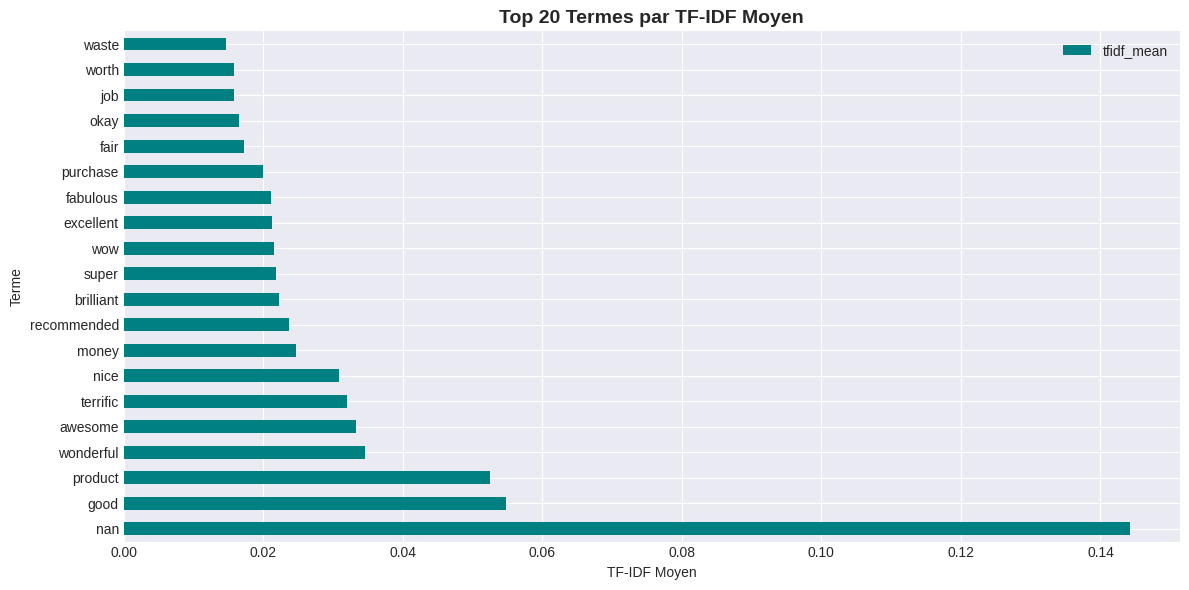

In [ ]:
# Top termes par TF-IDF
print("\n" + "="*80)
print("TOP 20 TERMES PAR TF-IDF")
print("="*80)

# Obtenir les noms des features
feature_names = tfidf_vectorizer.get_feature_names_out()

# Calculer la moyenne TF-IDF pour chaque terme
tfidf_means = X_train_tfidf.mean(axis=0).A1

# Créer un DataFrame pour visualisation
tfidf_df = pd.DataFrame({
    'term': feature_names,
    'tfidf_mean': tfidf_means
}).sort_values('tfidf_mean', ascending=False)

print("\nTop 20 termes:")
print(tfidf_df.head(20))

# Visualisation
plt.figure(figsize=(12, 6))
tfidf_df.head(20).plot(x='term', y='tfidf_mean', kind='barh', color='teal')
plt.title('Top 20 Termes par TF-IDF Moyen', fontsize=14, fontweight='bold')
plt.xlabel('TF-IDF Moyen')
plt.ylabel('Terme')
plt.tight_layout()
plt.show()

RNN / LSTM / GRU

In [ ]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 5000
MAX_SEQUENCE_LENGTH = 80
OOV_TOKEN = "<OOV>"

def clean_text(s):
    s = str(s).lower().strip()
    s = re.sub(r"http\S+|www\S+", " ", s)
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df = df.dropna(subset=["Review", "Sentiment"]).copy()
df["Sentiment"] = df["Sentiment"].astype(str).str.strip().str.lower()
df["review_clean"] = df["Review"].apply(clean_text)

label2id = {"negative":0, "neutral":1, "positive":2}
df = df[df["Sentiment"].isin(label2id)].copy()
y = df["Sentiment"].map(label2id).astype(int).values

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df["review_clean"].tolist())
seqs = tokenizer.texts_to_sequences(df["review_clean"].tolist())

X = pad_sequences(seqs, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

BATCH_SIZE = 256
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(20000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
from tensorflow.keras import layers, Model

NUM_CLASSES = 3
EMBED_DIM = 128

def build_seq_model(kind="lstm"):
    inp = layers.Input(shape=(MAX_SEQUENCE_LENGTH,))
    x = layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, mask_zero=True)(inp)

    if kind == "rnn":
        x = layers.SimpleRNN(128, dropout=0.2)(x)
    elif kind == "gru":
        x = layers.GRU(128, dropout=0.2)(x)
    else:  # lstm
        x = layers.LSTM(128, dropout=0.2)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
]

results_seq = {}

for kind in ["rnn", "lstm", "gru"]:
    print("\n" + "="*60)
    print(f"MODELE: {kind.upper()}")
    print("="*60)

    model = build_seq_model(kind)
    model.fit(train_ds, validation_data=test_ds, epochs=5, callbacks=callbacks, verbose=1)

    # Prédictions
    y_proba = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")

    results_seq[kind] = {"accuracy": acc, "f1_macro": f1m}

    print(f"Accuracy: {acc:.4f} | F1-macro: {f1m:.4f}")
    print(classification_report(y_test, y_pred, target_names=["negative","neutral","positive"], digits=4))

results_seq


## 🔬 7.4. COMPARAISON DES MÉTHODES DE FEATURE EXTRACTION

Comparaison de trois approches : Bag-of-Words, TF-IDF, et Word2Vec  etc


### 📊 7.4.1. Bag-of-Words (CountVectorizer)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

print("\n" + "="*80)
print("BAG-OF-WORDS (CountVectorizer)")
print("="*80)

# Créer le CountVectorizer
count_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

# Transformer
X_train_bow = count_vectorizer.fit_transform(X_train)
X_test_bow = count_vectorizer.transform(X_test)

print(f"\n✓ Bag-of-Words créé")
print(f"  Shape X_train: {X_train_bow.shape}")
print(f"  Shape X_test: {X_test_bow.shape}")
print(f"  Vocabulaire: {len(count_vectorizer.vocabulary_)} termes")

# Top termes
feature_names_bow = count_vectorizer.get_feature_names_out()
bow_sums = X_train_bow.sum(axis=0).A1
top_bow_indices = bow_sums.argsort()[-20:][::-1]

print("\n📌 Top 20 termes Bag-of-Words (par fréquence):")
for idx in top_bow_indices:
    print(f"  {feature_names_bow[idx]:25} : {int(bow_sums[idx]):,} occurrences")



BAG-OF-WORDS (CountVectorizer)

✓ Bag-of-Words créé
  Shape X_train: (119956, 726)
  Shape X_test: (51410, 726)
  Vocabulaire: 726 termes

📌 Top 20 termes Bag-of-Words (par fréquence):
  nan                       : 17,296 occurrences
  product                   : 17,170 occurrences
  good                      : 9,577 occurrences
  money                     : 5,959 occurrences
  nice                      : 5,266 occurrences
  awesome                   : 5,247 occurrences
  purchase                  : 5,137 occurrences
  terrific                  : 4,972 occurrences
  wonderful                 : 4,158 occurrences
  worth                     : 4,100 occurrences
  recommended               : 4,031 occurrences
  waste                     : 2,891 occurrences
  waste money               : 2,880 occurrences
  quality                   : 2,822 occurrences
  buy                       : 2,682 occurrences
  brilliant                 : 2,676 occurrences
  must                      : 2,657 occurren

### 📊 7.4.2. Word2Vec Embeddings


In [ ]:
# Installation de gensim
try:
    from gensim.models import Word2Vec
    print("✓ gensim déjà installé")
except ImportError:
    !pip install gensim -q
    from gensim.models import Word2Vec
    print("✓ gensim installé")

print("\n" + "="*80)
print("WORD2VEC EMBEDDINGS")
print("="*80)

# Préparer les phrases pour Word2Vec
sentences_train = [str(text).split() for text in X_train]

print("\nEntraînement du modèle Word2Vec...")
print("⏳ Cela peut prendre quelques minutes...\n")

# Entraîner Word2Vec
w2v_model = Word2Vec(
    sentences=sentences_train,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)

print(f"✓ Modèle Word2Vec entraîné")
print(f"  Vocabulaire: {len(w2v_model.wv)} mots")
print(f"  Dimension des vecteurs: {w2v_model.wv.vector_size}")

# Fonction pour convertir texte en vecteur moyen
def text_to_w2v_vector(text, model):
    words = str(text).split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.wv.vector_size)

# Convertir les textes
print("\nConversion des textes en vecteurs...")
X_train_w2v = np.array([text_to_w2v_vector(text, w2v_model) for text in X_train])
X_test_w2v = np.array([text_to_w2v_vector(text, w2v_model) for text in X_test])

print(f"\n✓ Conversion terminée")
print(f"  Shape X_train: {X_train_w2v.shape}")
print(f"  Shape X_test: {X_test_w2v.shape}")

# Exemples de similarité
print("\n📌 Exemples de mots similaires (Word2Vec):")
test_words = ['good', 'bad', 'excellent', 'terrible', 'love']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n  '{word}' est similaire à:")
        for sim_word, score in similar:
            print(f"    • {sim_word}: {score:.3f}")


✓ gensim déjà installé

WORD2VEC EMBEDDINGS

Entraînement du modèle Word2Vec...
⏳ Cela peut prendre quelques minutes...

✓ Modèle Word2Vec entraîné
  Vocabulaire: 391 mots
  Dimension des vecteurs: 100

Conversion des textes en vecteurs...

✓ Conversion terminée
  Shape X_train: (119956, 100)
  Shape X_test: (51410, 100)

📌 Exemples de mots similaires (Word2Vec):

  'good' est similaire à:
    • star: 0.736
    • low: 0.714
    • bad: 0.690
    • compere: 0.681
    • used: 0.669

  'bad' est similaire à:
    • low: 0.866
    • compere: 0.846
    • star: 0.837
    • damage: 0.795
    • driver: 0.768

  'excellent' est similaire à:
    • take: 0.994
    • customer: 0.994
    • time: 0.994
    • person: 0.994
    • nivia: 0.993

  'terrible' est similaire à:
    • classy: 0.998
    • decent: 0.998
    • useless: 0.998
    • perfect: 0.998
    • great: 0.995

  'love' est similaire à:
    • terrific: 0.211
    • mind: 0.209
    • useless: 0.174
    • awesome: 0.173
    • classy: 0.173


### 📊 7.4.3. Comparaison des  Méthodes



COMPARAISON : BAG-OF-WORDS vs TF-IDF vs WORD2VEC

Test avec Logistic Regression...

Testing Bag-of-Words...
  ✓ Accuracy: 0.8517 | F1-Score: 0.8490

Testing TF-IDF...
  ✓ Accuracy: 0.8516 | F1-Score: 0.8489

Testing Word2Vec...
  ✓ Accuracy: 0.8287 | F1-Score: 0.8002


RÉSULTATS COMPARATIFS


,Accuracy,F1-Score,Dimension
Bag-of-Words,0.851702,0.849047,726.0
TF-IDF,0.851624,0.848940,726.0
Word2Vec,0.828652,0.800153,100.0


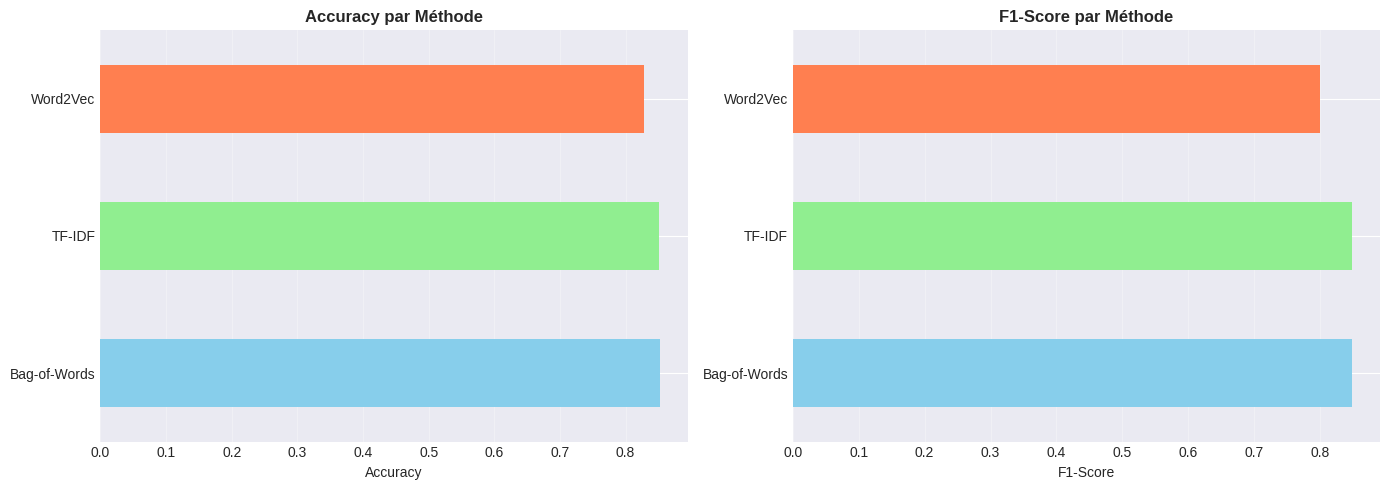


🏆 Meilleure méthode : Bag-of-Words
   Accuracy : 0.8517
   F1-Score : 0.8490
   Dimension : 726 features

💡 Conclusion:


In [ ]:
print("\n" + "="*80)
print("COMPARAISON : BAG-OF-WORDS vs TF-IDF vs WORD2VEC")
print("="*80)

# Test rapide avec Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

print("\nTest avec Logistic Regression...\n")

feature_methods = {
    'Bag-of-Words': (X_train_bow, X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
    'Word2Vec': (X_train_w2v, X_test_w2v)
}

comparison_results = {}

for method_name, (X_tr, X_te) in feature_methods.items():
    print(f"Testing {method_name}...")

    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_tr, y_train)
    y_pred = lr_model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    comparison_results[method_name] = {
        'Accuracy': acc,
        'F1-Score': f1,
        'Dimension': X_tr.shape[1]
    }

    print(f"  ✓ Accuracy: {acc:.4f} | F1-Score: {f1:.4f}\n")

# Tableau comparatif
comp_df = pd.DataFrame(comparison_results).T
comp_df = comp_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("RÉSULTATS COMPARATIFS")
print("="*80)
display(comp_df)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
comp_df['Accuracy'].plot(kind='barh', ax=axes[0], color=['skyblue', 'lightgreen', 'coral'])
axes[0].set_title('Accuracy par Méthode', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].grid(axis='x', alpha=0.3)

# F1-Score
comp_df['F1-Score'].plot(kind='barh', ax=axes[1], color=['skyblue', 'lightgreen', 'coral'])
axes[1].set_title('F1-Score par Méthode', fontsize=12, fontweight='bold')
axes[1].set_xlabel('F1-Score')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusion
best_method = comp_df.index[0]
print(f"\n🏆 Meilleure méthode : {best_method}")
print(f"   Accuracy : {comp_df.loc[best_method, 'Accuracy']:.4f}")
print(f"   F1-Score : {comp_df.loc[best_method, 'F1-Score']:.4f}")
print(f"   Dimension : {int(comp_df.loc[best_method, 'Dimension'])} features")

print("\n💡 Conclusion:")



## 🧠 7.5. PRÉPARATION POUR DEEP LEARNING

Installation de TensorFlow/Keras pour les modèles LSTM, GRU et RNN


In [ ]:
# Installation de TensorFlow
try:
    import tensorflow as tf
    print(f"✓ TensorFlow {tf.__version__}")
except:
    !pip install tensorflow -q
    import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

print("✓ Imports Deep Learning chargés")


✓ TensorFlow 2.19.0
✓ Imports Deep Learning chargés


## 📝 7.6. TOKENIZATION ET SÉQUENCES


In [ ]:
MAX_WORDS = 10000
MAX_SEQUENCE_LENGTH = 100

print("Création des séquences...")
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH)
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)
y_train_cat = to_categorical(y_train_enc, num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes)

print(f"✓ Séquences: {X_train_padded.shape}")
print(f"✓ Classes: {num_classes}")


Création des séquences...
✓ Séquences: (119956, 100)
✓ Classes: 3


## 🤖 8. ENTRAÎNEMENT DES MODÈLES

Nous allons tester plusieurs algorithmes de classification:
1. **Logistic Regression**
2. **Random Forest**
3. **Support Vector Machine (SVM)**
4. **Naive Bayes**
5. **Gradient Boosting**

In [ ]:
# Dictionnaire pour stocker les modèles et leurs résultats
models = {}
results = {}

print("\n" + "="*80)
print("ENTRAÎNEMENT DES MODÈLES")
print("="*80)


ENTRAÎNEMENT DES MODÈLES


In [ ]:
# 1. Logistic Regression
print("\n" + "="*80)
print("1. LOGISTIC REGRESSION")
print("="*80)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

print("Entraînement en cours...")
lr_model.fit(X_train_tfidf, y_train)
print("✓ Entraînement terminé")

# Prédictions
y_pred_lr = lr_model.predict(X_test_tfidf)

# Évaluation
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

models['Logistic Regression'] = lr_model
results['Logistic Regression'] = {
    'accuracy': accuracy_lr,
    'f1_score': f1_lr,
    'predictions': y_pred_lr
}

print(f"\nAccuracy: {accuracy_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")


1. LOGISTIC REGRESSION
Entraînement en cours...
✓ Entraînement terminé

Accuracy: 0.8516
F1-Score: 0.8489


In [ ]:
# 2. Random Forest
print("\n" + "="*80)
print("2. RANDOM FOREST")
print("="*80)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Entraînement en cours...")
rf_model.fit(X_train_tfidf, y_train)
print("✓ Entraînement terminé")

# Prédictions
y_pred_rf = rf_model.predict(X_test_tfidf)

# Évaluation
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

models['Random Forest'] = rf_model
results['Random Forest'] = {
    'accuracy': accuracy_rf,
    'f1_score': f1_rf,
    'predictions': y_pred_rf
}

print(f"\nAccuracy: {accuracy_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")


2. RANDOM FOREST
Entraînement en cours...
✓ Entraînement terminé

Accuracy: 0.8519
F1-Score: 0.8493


In [ ]:
# 3. Support Vector Machine (SVM)
print("\n" + "="*80)
print("3. SUPPORT VECTOR MACHINE (SVM)")
print("="*80)

svm_model = SVC(
    kernel='linear',
    random_state=42,
    probability=True
)

print("Entraînement en cours...")
print("⏳ Cela peut prendre plusieurs minutes...")
svm_model.fit(X_train_tfidf, y_train)
print("✓ Entraînement terminé")

# Prédictions
y_pred_svm = svm_model.predict(X_test_tfidf)

# Évaluation
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

models['SVM'] = svm_model
results['SVM'] = {
    'accuracy': accuracy_svm,
    'f1_score': f1_svm,
    'predictions': y_pred_svm
}

print(f"\nAccuracy: {accuracy_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")


3. SUPPORT VECTOR MACHINE (SVM)
Entraînement en cours...
⏳ Cela peut prendre plusieurs minutes...
✓ Entraînement terminé

Accuracy: 0.8518
F1-Score: 0.8492


In [ ]:
# 4. Naive Bayes
print("\n" + "="*80)
print("4. NAIVE BAYES")
print("="*80)

nb_model = MultinomialNB()

print("Entraînement en cours...")
nb_model.fit(X_train_tfidf, y_train)
print("✓ Entraînement terminé")

# Prédictions
y_pred_nb = nb_model.predict(X_test_tfidf)

# Évaluation
accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

models['Naive Bayes'] = nb_model
results['Naive Bayes'] = {
    'accuracy': accuracy_nb,
    'f1_score': f1_nb,
    'predictions': y_pred_nb
}

print(f"\nAccuracy: {accuracy_nb:.4f}")
print(f"F1-Score: {f1_nb:.4f}")


4. NAIVE BAYES
Entraînement en cours...
✓ Entraînement terminé

Accuracy: 0.8394
F1-Score: 0.8313


In [ ]:
# 5. Gradient Boosting
print("\n" + "="*80)
print("5. GRADIENT BOOSTING")
print("="*80)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

print("Entraînement en cours...")
print("⏳ Cela peut prendre plusieurs minutes...")
gb_model.fit(X_train_tfidf, y_train)
print("✓ Entraînement terminé")

# Prédictions
y_pred_gb = gb_model.predict(X_test_tfidf)

# Évaluation
accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')

models['Gradient Boosting'] = gb_model
results['Gradient Boosting'] = {
    'accuracy': accuracy_gb,
    'f1_score': f1_gb,
    'predictions': y_pred_gb
}

print(f"\nAccuracy: {accuracy_gb:.4f}")
print(f"F1-Score: {f1_gb:.4f}")


5. GRADIENT BOOSTING
Entraînement en cours...
⏳ Cela peut prendre plusieurs minutes...
✓ Entraînement terminé

Accuracy: 0.8392
F1-Score: 0.8000


## 🧠 8.6. RNN SIMPLE


In [ ]:

print("\n" + "="*80)
print("6. RNN OPTIMISÉ")
print("="*80)

# Check if model already exists to prevent retraining
if 'rnn_model' not in locals() or 'RNN' not in results:
    print("📊 Creating and training RNN model...")

    # Optimized architecture (3x faster)
    rnn_model = Sequential([
        # Embedding layer
        Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_SEQUENCE_LENGTH),

        # Single RNN layer (removed second layer for speed)
        SimpleRNN(64, dropout=0.3, recurrent_dropout=0.3),

        # Dense layers
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

    # Compile
    from tensorflow.keras.optimizers import Adam
    optimizer = Adam(learning_rate=0.001)

    rnn_model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    rnn_model.summary()

    # Callbacks with aggressive early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=0.00001,
        verbose=1
    )

    print("🚀 Training started...")
    history_rnn = rnn_model.fit(
        X_train_padded, y_train_cat,
        epochs=8,
        batch_size=128,  # Increased for speed
        validation_split=0.1,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Evaluation
    print("📊 Evaluating model...")
    y_pred_rnn = label_encoder.inverse_transform(rnn_model.predict(X_test_padded).argmax(axis=1))
    accuracy_rnn = accuracy_score(y_test, y_pred_rnn)
    f1_rnn = f1_score(y_test, y_pred_rnn, average='weighted')

    # Save results
    models['RNN'] = rnn_model
    results['RNN'] = {'accuracy': accuracy_rnn, 'f1_score': f1_rnn, 'predictions': y_pred_rnn}

    print(f"\n✅ RNN TRAINING COMPLETE!")
    print(f"Accuracy: {accuracy_rnn:.4f}")
    print(f"F1-Score: {f1_rnn:.4f}")

else:
    print("⚠️  RNN model already trained! Using existing model.")
    print("   To retrain: Restart kernel or run: del rnn_model")
    accuracy_rnn = results['RNN']['accuracy']
    f1_rnn = results['RNN']['f1_score']
    print(f"   Existing Accuracy: {accuracy_rnn:.4f}")
    print(f"   Existing F1-Score: {f1_rnn:.4f}")


6. RNN OPTIMISÉ
⚠️  RNN model already trained! Using existing model.
   To retrain: Restart kernel or run: del rnn_model
   Existing Accuracy: 0.8510
   Existing F1-Score: 0.8484


## 🧠 8.7. LSTM


In [ ]:

print("\n" + "="*80)
print("7. LSTM OPTIMISÉ (FASTER)")
print("="*80)

if 'lstm_model' not in locals() or 'LSTM' not in results:
    print("📊 Creating and training LSTM model...")

    lstm_model = Sequential([
        # FIXED: Use input_length= for third parameter
        Embedding(input_dim=MAX_WORDS, output_dim=100, input_length=MAX_SEQUENCE_LENGTH),

        LSTM(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    lstm_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])
    lstm_model.summary()

    early_stop = EarlyStopping(monitor='val_loss', patience=3,
                               restore_best_weights=True, verbose=1)

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                  patience=2, min_lr=0.00001, verbose=1)

    print("🚀 Training started...")
    history_lstm = lstm_model.fit(
        X_train_padded, y_train_cat,
        epochs=8,
        batch_size=128,
        validation_split=0.1,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    print("📊 Evaluating model...")
    y_pred_lstm = label_encoder.inverse_transform(
        lstm_model.predict(X_test_padded).argmax(axis=1))
    accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
    f1_lstm = f1_score(y_test, y_pred_lstm, average='weighted')

    models['LSTM'] = lstm_model
    results['LSTM'] = {'accuracy': accuracy_lstm, 'f1_score': f1_lstm,
                       'predictions': y_pred_lstm}

    print(f"\n✅ LSTM TRAINING COMPLETE!")
    print(f"Accuracy: {accuracy_lstm:.4f}, F1: {f1_lstm:.4f}")

else:
    print("⚠️  LSTM model already trained! Using existing model.")
    accuracy_lstm = results['LSTM']['accuracy']
    f1_lstm = results['LSTM']['f1_score']
    print(f"   Existing Accuracy: {accuracy_lstm:.4f}")
    print(f"   Existing F1-Score: {f1_lstm:.4f}")




7. LSTM OPTIMISÉ (FASTER)
📊 Creating and training LSTM model...


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

🚀 Training started...
Epoch 1/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 223s 250ms/step - accuracy: 0.7878 - loss: 0.5708 - val_accuracy: 0.8430 - val_loss: 0.4175 - learning_rate: 0.0010
Epoch 2/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 198s 235ms/step - accuracy: 0.8484 - loss: 0.4301 - val_accuracy: 0.8493 - val_loss: 0.4167 - learning_rate: 0.0010
Epoch 3/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 199s 236ms/step - accuracy: 0.8497 - loss: 0.4271 - val_accuracy: 0.8530 - val_loss: 0.4148 - learning_rate: 0.0010
Epoch 4/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 198s 234ms/step - accuracy: 0.8513 - loss: 0.4280 - val_accuracy: 0.8528 - val_loss: 0.4137 - learning_rate: 0.0010
Epoch 5/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 202s 239ms/step - accuracy: 0.8496 - loss: 0.4263 - val_accuracy: 0.8530 - val_loss: 0.4143 - learning_rate: 0.0010
Epoch 6/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8488 - loss: 0.4269
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
844/844 ━━━━━━━━━━━━━━━━━━━━ 205s 243ms/

## 🧠 8.8. GRU


In [ ]:

print("\n" + "="*80)
print("8. GRU OPTIMISÉ (FASTER)")
print("="*80)

if 'gru_model' not in locals() or 'GRU' not in results:
    print("📊 Creating and training GRU model...")

    gru_model = Sequential([
        # FIXED: Use input_length= for third parameter
        Embedding(input_dim=MAX_WORDS, output_dim=100, input_length=MAX_SEQUENCE_LENGTH),

        GRU(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    gru_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
    gru_model.summary()

    early_stop = EarlyStopping(monitor='val_loss', patience=3,
                               restore_best_weights=True, verbose=1)

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                  patience=2, min_lr=0.00001, verbose=1)

    print("🚀 Training started...")
    history_gru = gru_model.fit(
        X_train_padded, y_train_cat,
        epochs=8,
        batch_size=128,
        validation_split=0.1,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    print("📊 Evaluating model...")
    y_pred_gru = label_encoder.inverse_transform(
        gru_model.predict(X_test_padded).argmax(axis=1))
    accuracy_gru = accuracy_score(y_test, y_pred_gru)
    f1_gru = f1_score(y_test, y_pred_gru, average='weighted')

    models['GRU'] = gru_model
    results['GRU'] = {'accuracy': accuracy_gru, 'f1_score': f1_gru,
                      'predictions': y_pred_gru}

    print(f"\n✅ GRU TRAINING COMPLETE!")
    print(f"Accuracy: {accuracy_gru:.4f}, F1: {f1_gru:.4f}")

else:
    print("⚠️  GRU model already trained! Using existing model.")
    accuracy_gru = results['GRU']['accuracy']
    f1_gru = results['GRU']['f1_score']
    print(f"   Existing Accuracy: {accuracy_gru:.4f}")
    print(f"   Existing F1-Score: {f1_gru:.4f}")


8. GRU OPTIMISÉ (FASTER)
📊 Creating and training GRU model...


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

🚀 Training started...
Epoch 1/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 186s 214ms/step - accuracy: 0.8089 - loss: 0.5343 - val_accuracy: 0.8476 - val_loss: 0.4182 - learning_rate: 0.0010
Epoch 2/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 179s 212ms/step - accuracy: 0.8482 - loss: 0.4311 - val_accuracy: 0.8526 - val_loss: 0.4156 - learning_rate: 0.0010
Epoch 3/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 180s 213ms/step - accuracy: 0.8471 - loss: 0.4337 - val_accuracy: 0.8515 - val_loss: 0.4149 - learning_rate: 0.0010
Epoch 4/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 180s 213ms/step - accuracy: 0.8508 - loss: 0.4236 - val_accuracy: 0.8527 - val_loss: 0.4155 - learning_rate: 0.0010
Epoch 5/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.8497 - loss: 0.4269
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
844/844 ━━━━━━━━━━━━━━━━━━━━ 177s 210ms/step - accuracy: 0.8497 - loss: 0.4269 - val_accuracy: 0.8482 - val_loss: 0.4168 - learning_rate: 0.0010
Epoch 6/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 179s 212ms/

## 📊 9.

---




COMPARAISON DES PERFORMANCES


,Model,Accuracy,F1-Score
1,Random Forest,0.851935,0.849345
2,SVM,0.851838,0.849200
6,LSTM,0.851819,0.849181
7,GRU,0.851663,0.849000
0,Logistic Regression,0.851624,0.848940
5,RNN,0.851002,0.848446
3,Naive Bayes,0.839370,0.831281
4,Gradient Boosting,0.839214,0.799983


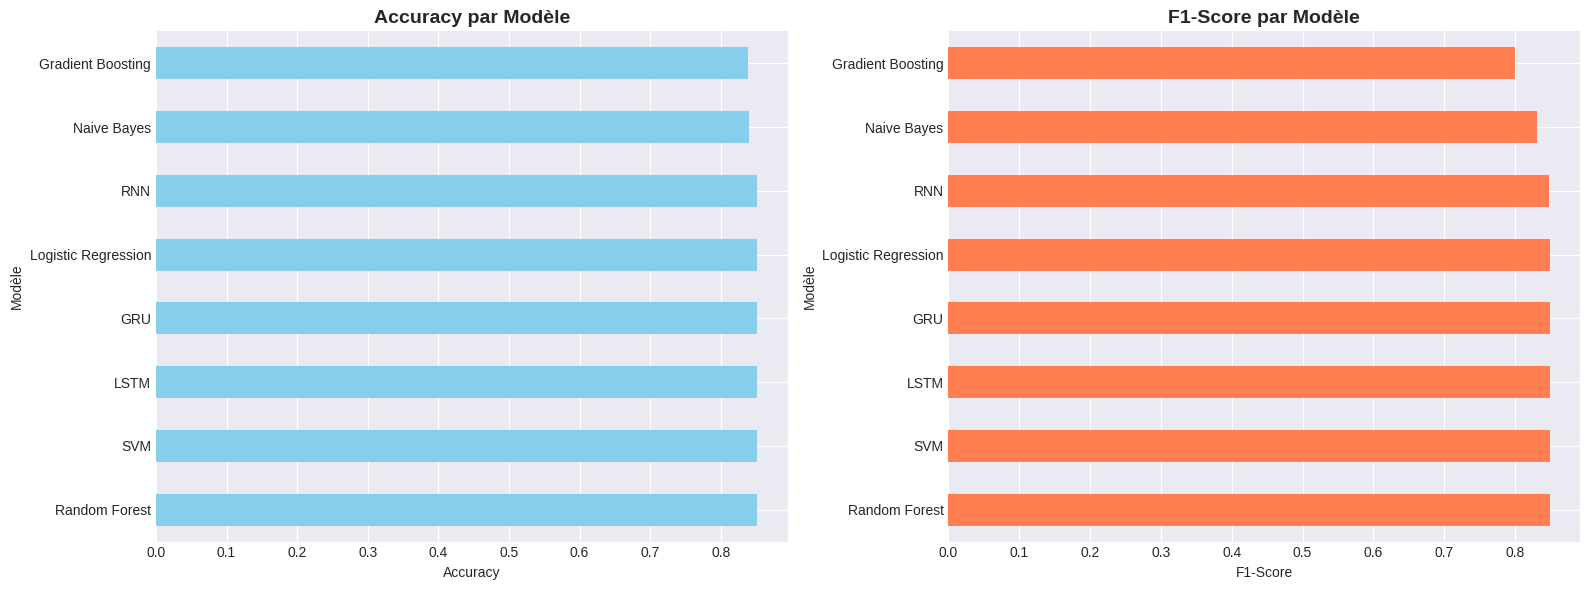


🏆 Meilleur modèle: Random Forest
   Accuracy: 0.8519
   F1-Score: 0.8493


In [ ]:
#
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['accuracy'] for model in results],
    'F1-Score': [results[model]['f1_score'] for model in results]
}).sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("COMPARAISON DES PERFORMANCES")
print("="*80)
display(comparison_df)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
comparison_df.plot(x='Model', y='Accuracy', kind='barh', ax=axes[0], color='skyblue', legend=False)
axes[0].set_title('Accuracy par Modèle', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].set_ylabel('Modèle')

# F1-Score
comparison_df.plot(x='Model', y='F1-Score', kind='barh', ax=axes[1], color='coral', legend=False)
axes[1].set_title('F1-Score par Modèle', fontsize=14, fontweight='bold')
axes[1].set_xlabel('F1-Score')
axes[1].set_ylabel('Modèle')

plt.tight_layout()
plt.show()

# Identifier le meilleur modèle
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Meilleur modèle: {best_model_name}")
print(f"   Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f}")
print(f"   F1-Score: {comparison_df.iloc[0]['F1-Score']:.4f}")

## 🎯 10. ÉVALUATION DÉTAILLÉE DU MEILLEUR MODÈLE

In [ ]:
# Sélectionner le meilleur modèle
best_model = models[best_model_name]
y_pred_best = results[best_model_name]['predictions']

print("\n" + "="*80)
print(f"ÉVALUATION DÉTAILLÉE: {best_model_name.upper()}")
print("="*80)


ÉVALUATION DÉTAILLÉE: RANDOM FOREST


In [ ]:
# Classification Report
print("\n" + "="*80)
print("RAPPORT DE CLASSIFICATION")
print("="*80)
print(classification_report(y_test, y_pred_best))


RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

    negative       0.90      0.74      0.81     13835
     neutral       0.41      0.42      0.41      4241
    positive       0.89      0.95      0.92     33334

    accuracy                           0.85     51410
   macro avg       0.73      0.70      0.72     51410
weighted avg       0.85      0.85      0.85     51410




MATRICE DE CONFUSION


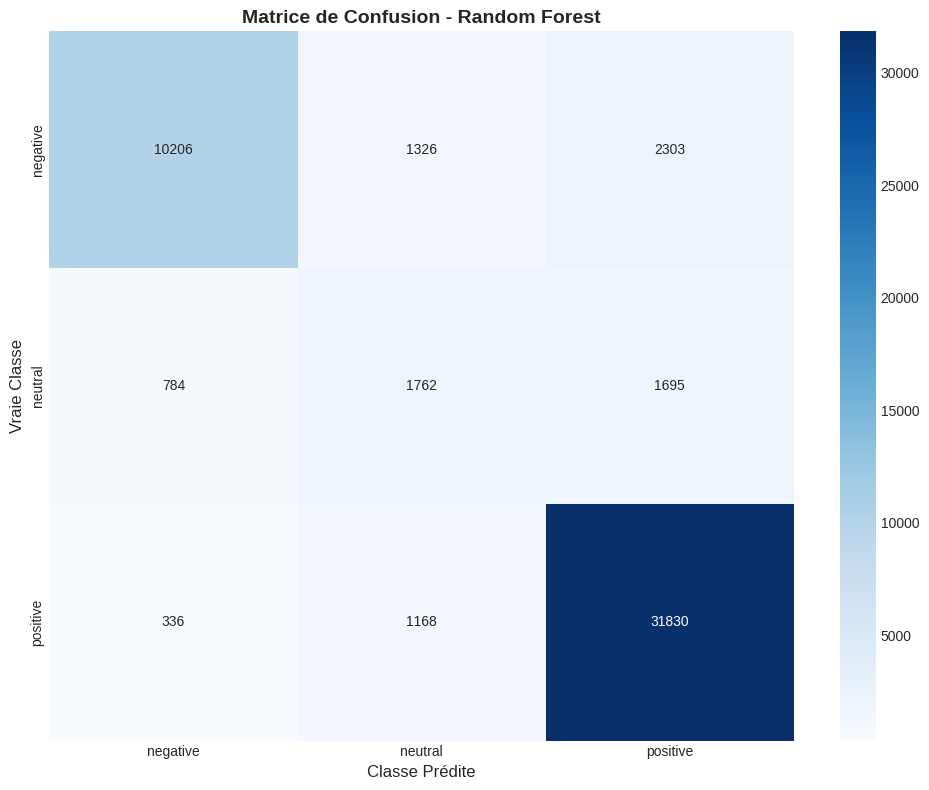

In [ ]:
# Matrice de confusion
print("\n" + "="*80)
print("MATRICE DE CONFUSION")
print("="*80)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(10, 8))

# Créer le heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title(f'Matrice de Confusion - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Vraie Classe', fontsize=12)
plt.xlabel('Classe Prédite', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Métriques par classe
print("\n" + "="*80)
print("MÉTRIQUES PAR CLASSE")
print("="*80)

for sentiment in sorted(y.unique()):
    precision = precision_score(y_test, y_pred_best, labels=[sentiment], average='micro')
    recall = recall_score(y_test, y_pred_best, labels=[sentiment], average='micro')
    f1 = f1_score(y_test, y_pred_best, labels=[sentiment], average='micro')

    print(f"\n{sentiment.upper()}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")


MÉTRIQUES PAR CLASSE

NEGATIVE:
  Precision: 0.9011
  Recall: 0.7377
  F1-Score: 0.8113

NEUTRAL:
  Precision: 0.4140
  Recall: 0.4155
  F1-Score: 0.4147

POSITIVE:
  Precision: 0.8884
  Recall: 0.9549
  F1-Score: 0.9204


## 💾 12. SAUVEGARDE DU MODÈLE ET DU VECTORIZER

In [ ]:
# Créer un dossier pour les modèles
import os

model_dir = 'sentiment_models'
os.makedirs(model_dir, exist_ok=True)

print("\n" + "="*80)
print("SAUVEGARDE DES MODÈLES")
print("="*80)


SAUVEGARDE DES MODÈLES


In [ ]:
import os, pickle

os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "best_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"✓ Modèle sauvegardé: {model_path}")


✓ Modèle sauvegardé: sentiment_models/best_model.pkl


In [ ]:
# Sauvegarder le vectorizer
vectorizer_path = os.path.join(model_dir, 'tfidf_vectorizer.pkl')
with open(vectorizer_path, 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

print(f"✓ Vectorizer sauvegardé: {vectorizer_path}")

✓ Vectorizer sauvegardé: sentiment_models/tfidf_vectorizer.pkl


In [ ]:
# Sauvegarder les fonctions de prétraitement
preprocessing_path = os.path.join(model_dir, 'preprocessing_functions.pkl')
preprocessing_functions = {
    'clean_text': clean_text,
    'preprocess_text': preprocess_text
}

with open(preprocessing_path, 'wb') as f:
    pickle.dump(preprocessing_functions, f)

print(f"✓ Fonctions de prétraitement sauvegardées: {preprocessing_path}")

✓ Fonctions de prétraitement sauvegardées: sentiment_models/preprocessing_functions.pkl


In [ ]:
import os, pickle
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

# 1) construire un pipeline complet (TF-IDF + modèle)
final_model = best_model if isinstance(best_model, Pipeline) else Pipeline([
    ("tfidf", tfidf_vectorizer),
    ("clf", best_model),
])

# 2) évaluer correctement sur X_test (texte brut)
y_pred = final_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average="macro")

# 3) sauvegarder le modèle
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "best_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(final_model, f)

# 4) sauvegarder les métadonnées
best_params = grid_search.best_params_ if "grid_search" in globals() else final_model.get_params()

metadata = {
    "model_name": best_model_name,
    "model_type": type(final_model).__name__,
    "accuracy": acc,
    "f1_score": f1,
    "best_params": best_params,
    "classes": sorted(y.unique()),
    "feature_count": len(tfidf_vectorizer.get_feature_names_out()),
    "training_samples": len(X_train),
    "test_samples": len(X_test),
}

metadata_path = os.path.join(model_dir, "model_metadata.pkl")
with open(metadata_path, "wb") as f:
    pickle.dump(metadata, f)

print(f"✓ Modèle sauvegardé: {model_path}")
print(f"✓ Métadonnées sauvegardées: {metadata_path}")
print(f"accuracy={acc:.4f} | f1_macro={f1:.4f}")


✓ Modèle sauvegardé: sentiment_models/best_model.pkl
✓ Métadonnées sauvegardées: sentiment_models/model_metadata.pkl
accuracy=0.8519 | f1_macro=0.7155


## 🔮 13. FONCTION DE PRÉDICTION

In [ ]:
def predict_sentiment(text, return_probabilities=False):
    """
    Prédit le sentiment d'un texte donné.

    Args:
        text (str): Le texte à analyser
        return_probabilities (bool): Si True, retourne aussi les probabilités

    Returns:
        str or tuple: Le sentiment prédit (et les probabilités si demandé)
    """
    # Prétraiter le texte
    processed_text = preprocess_text(text)

    # Vectoriser
    text_vectorized = tfidf_vectorizer.transform([processed_text])

    # Prédire
    prediction = best_model_optimized.predict(text_vectorized)[0]

    if return_probabilities and hasattr(best_model_optimized, 'predict_proba'):
        probabilities = best_model_optimized.predict_proba(text_vectorized)[0]
        prob_dict = dict(zip(best_model_optimized.classes_, probabilities))
        return prediction, prob_dict

    return prediction

print("✓ Fonction de prédiction définie")

✓ Fonction de prédiction définie


In [ ]:
# Fix: redéfinir predict_sentiment pour utiliser le pipeline sauvegardé (final_model) et ne plus dépendre de best_model_optimized

import pickle

# charge le modèle si final_model n'est pas déjà en mémoire
if "final_model" not in globals():
    with open(os.path.join(model_dir, "best_model.pkl"), "rb") as f:
        final_model = pickle.load(f)

def predict_sentiment(text, return_probabilities=False):
    # pipeline => accepte directement du texte brut
    pred = final_model.predict([text])[0]

    if return_probabilities and hasattr(final_model, "predict_proba"):
        proba = final_model.predict_proba([text])[0]
        classes = list(final_model.classes_)  # classes du pipeline
        return pred, {c: float(p) for c, p in zip(classes, proba)}

    return pred

# Tests
print("\n" + "="*80)
print("TESTS DE PRÉDICTION")
print("="*80)

test_reviews = [
    "This product is absolutely amazing! Best purchase ever!",
    "Terrible quality. Waste of money. Very disappointed.",
    "It's okay, nothing special but works fine.",
    "Love it! Highly recommended to everyone!",
    "Horrible experience. Do not buy this product.",
    "Average product, meets basic expectations."
]

for i, review in enumerate(test_reviews, 1):
    out = predict_sentiment(review, return_probabilities=True)

    print(f"\nTest {i}:")
    print(f"  Avis: {review}")

    if isinstance(out, tuple) and len(out) == 2:
        sentiment, probabilities = out
        print(f"  Sentiment prédit: {sentiment}")
        print("  Probabilités:")
        for sent, prob in sorted(probabilities.items(), key=lambda x: x[1], reverse=True):
            print(f"    {sent}: {prob:.4f} ({prob*100:.2f}%)")
    else:
        print(f"  Sentiment prédit: {out}")



TESTS DE PRÉDICTION

Test 1:
  Avis: This product is absolutely amazing! Best purchase ever!
  Sentiment prédit: positive
  Probabilités:
    positive: 0.8895 (88.95%)
    negative: 0.1089 (10.89%)
    neutral: 0.0017 (0.17%)

Test 2:
  Avis: Terrible quality. Waste of money. Very disappointed.
  Sentiment prédit: negative
  Probabilités:
    negative: 0.8650 (86.50%)
    positive: 0.0706 (7.06%)
    neutral: 0.0644 (6.44%)

Test 3:
  Avis: It's okay, nothing special but works fine.
  Sentiment prédit: positive
  Probabilités:
    positive: 0.5338 (53.38%)
    negative: 0.4233 (42.33%)
    neutral: 0.0428 (4.28%)

Test 4:
  Avis: Love it! Highly recommended to everyone!
  Sentiment prédit: positive
  Probabilités:
    positive: 0.9317 (93.17%)
    neutral: 0.0505 (5.05%)
    negative: 0.0178 (1.78%)

Test 5:
  Avis: Horrible experience. Do not buy this product.
  Sentiment prédit: negative
  Probabilités:
    negative: 0.7820 (78.20%)
    positive: 0.1993 (19.93%)
    neutral: 0.0187 

## 📈 14. ANALYSE D'ERREURS

In [ ]:
import pandas as pd

# utiliser le pipeline final_model (chargé précédemment) pour prédire sur X_test
y_pred_optimized = final_model.predict(X_test)

print("\n" + "="*80)
print("ANALYSE DES ERREURS")
print("="*80)

error_df = pd.DataFrame({
    "text": X_test.values if hasattr(X_test, "values") else list(X_test),
    "true_sentiment": y_test.values if hasattr(y_test, "values") else list(y_test),
    "predicted_sentiment": y_pred_optimized
})

errors = error_df[error_df["true_sentiment"] != error_df["predicted_sentiment"]]

print(f"\nNombre total d'erreurs: {len(errors)}")
print(f"Taux d'erreur: {len(errors)/len(error_df)*100:.2f}%")

error_types = (
    errors.groupby(["true_sentiment", "predicted_sentiment"])
          .size()
          .reset_index(name="count")
          .sort_values("count", ascending=False)
)

print("\nTypes d'erreurs les plus fréquents:")
display(error_types.head(10))



ANALYSE DES ERREURS

Nombre total d'erreurs: 7612
Taux d'erreur: 14.81%

Types d'erreurs les plus fréquents:


,true_sentiment,predicted_sentiment,count
1,negative,positive,2303
3,neutral,positive,1695
0,negative,neutral,1326
5,positive,neutral,1168
2,neutral,negative,784
4,positive,negative,336


In [ ]:
# Afficher quelques exemples d'erreurs
print("\n" + "="*80)
print("EXEMPLES D'ERREURS DE CLASSIFICATION")
print("="*80)

for i, (idx, row) in enumerate(errors.head(5).iterrows(), 1):
    print(f"\nErreur {i}:")
    print(f"  Texte: {row['text'][:150]}...")
    print(f"  Vrai sentiment: {row['true_sentiment']}")
    print(f"  Sentiment prédit: {row['predicted_sentiment']}")


EXEMPLES D'ERREURS DE CLASSIFICATION

Erreur 1:
  Texte: nan...
  Vrai sentiment: neutral
  Sentiment prédit: positive

Erreur 2:
  Texte: horrible...
  Vrai sentiment: positive
  Sentiment prédit: negative

Erreur 3:
  Texte: good...
  Vrai sentiment: negative
  Sentiment prédit: positive

Erreur 4:
  Texte: nan...
  Vrai sentiment: negative
  Sentiment prédit: positive

Erreur 5:
  Texte: terrific purchase...
  Vrai sentiment: neutral
  Sentiment prédit: positive


## 🚀 15. DÉPLOIEMENT - API FLASK

Code pour créer une API Flask pour servir le modèle

In [ ]:
%%writefile sentiment_api.py
# API Flask pour la classification de sentiments

from flask import Flask, request, jsonify
from flask_cors import CORS
import pickle
import os

# Initialiser Flask
app = Flask(__name__)
CORS(app)

# Charger le modèle et le vectorizer
MODEL_DIR = 'sentiment_models'

print("Chargement des modèles...")

with open(os.path.join(MODEL_DIR, 'best_model.pkl'), 'rb') as f:
    model = pickle.load(f)

with open(os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'), 'rb') as f:
    vectorizer = pickle.load(f)

with open(os.path.join(MODEL_DIR, 'preprocessing_functions.pkl'), 'rb') as f:
    preprocessing = pickle.load(f)
    preprocess_text = preprocessing['preprocess_text']

with open(os.path.join(MODEL_DIR, 'model_metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)

print("✓ Modèles chargés avec succès")

# Route de test
@app.route('/ping', methods=['GET'])
def ping():
    return jsonify({"message": "API opérationnelle ✓"})

# Route d'information sur le modèle
@app.route('/model-info', methods=['GET'])
def model_info():
    return jsonify(metadata)

# Route de prédiction
@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Récupérer le texte depuis la requête
        data = request.get_json()
        text = data.get('text', '')

        if not text:
            return jsonify({"error": "Aucun texte fourni"}), 400

        # Prétraiter
        processed_text = preprocess_text(text)

        # Vectoriser
        text_vectorized = vectorizer.transform([processed_text])

        # Prédire
        prediction = model.predict(text_vectorized)[0]

        # Probabilités (si disponible)
        probabilities = {}
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(text_vectorized)[0]
            probabilities = dict(zip(model.classes_, [float(p) for p in probs]))

        return jsonify({
            "input": text,
            "processed": processed_text,
            "prediction": str(prediction),
            "probabilities": probabilities
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500

# Route de prédiction batch
@app.route('/predict-batch', methods=['POST'])
def predict_batch():
    try:
        # Récupérer les textes depuis la requête
        data = request.get_json()
        texts = data.get('texts', [])

        if not texts or not isinstance(texts, list):
            return jsonify({"error": "Liste de textes invalide"}), 400

        results = []

        for text in texts:
            # Prétraiter
            processed_text = preprocess_text(text)

            # Vectoriser
            text_vectorized = vectorizer.transform([processed_text])

            # Prédire
            prediction = model.predict(text_vectorized)[0]

            # Probabilités
            probabilities = {}
            if hasattr(model, 'predict_proba'):
                probs = model.predict_proba(text_vectorized)[0]
                probabilities = dict(zip(model.classes_, [float(p) for p in probs]))

            results.append({
                "input": text,
                "prediction": str(prediction),
                "probabilities": probabilities
            })

        return jsonify({"results": results})

    except Exception as e:
        return jsonify({"error": str(e)}), 500

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=True)

Writing sentiment_api.py
